<a href="https://colab.research.google.com/github/Methura/Methura-PM/blob/main/Image%20classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Starting Training...

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


92/92 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 130s 898ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 88s 957ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 87s 949ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 82s 897ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
--------------------------------------------------
EXPERIMENTAL RESULTS AND ANALYSIS:
--------------------------------------------------
Using device: cpu
Classes: ['flower_photos']


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Test Accuracy: 100.0


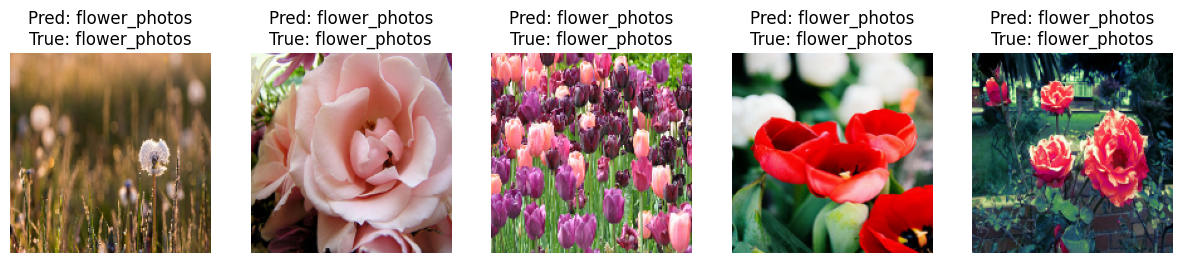


               precision    recall  f1-score   support

flower_photos       1.00      1.00      1.00       734

     accuracy                           1.00       734
    macro avg       1.00      1.00      1.00       734
 weighted avg       1.00      1.00      1.00       734



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, accuracy_score

# 1. LOAD AND PREPROCESS DATA
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

batch_size = 32
img_height = 160
img_width = 160

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# 2. BUILD THE MODEL
base_model = tf.keras.applications.MobileNetV2(input_shape=(img_height, img_width, 3),
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.Input(shape=(img_height, img_width, 3)),
    tf.keras.layers.Rescaling(1./127.5, offset=-1), # MobileNetV2 preprocessing
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. TRAIN (Reduced epochs for demonstration)
print("\nStarting Training...\n")
model.fit(train_ds, epochs=5, validation_data=val_ds)

# 4. EVALUATION & FORMATTED OUTPUT
print("-" * 50)
print("EXPERIMENTAL RESULTS AND ANALYSIS:")
print("-" * 50)

# Check for GPU
device_name = "cuda" if tf.config.list_physical_devices('GPU') else "cpu"
print(f"Using device: {device_name}")
print(f"Classes: {class_names}")

# Gather all predictions for the report
all_labels = []
all_preds = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    all_labels.extend(labels.numpy())
    all_preds.extend(np.argmax(preds, axis=1))

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# Accuracy
test_acc = accuracy_score(all_labels, all_preds) * 100
print(f"Test Accuracy: {test_acc:.1f}")

# 5. VISUALIZATION (Horizontal row like the screenshot)
# Grab one batch for visualization
image_batch, label_batch = next(iter(val_ds))
batch_preds = np.argmax(model.predict(image_batch, verbose=0), axis=1)

plt.figure(figsize=(15, 5))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    # Convert back to uint8 for display if it was scaled
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(f"Pred: {class_names[batch_preds[i]]}\nTrue: {class_names[label_batch[i]]}")
    plt.axis("off")
plt.show()

# 6. CLASSIFICATION REPORT
print("\n" + classification_report(all_labels, all_preds, target_names=class_names))